In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import joblib
from scipy import stats

In [2]:
BG, CARD = '#0d1117', '#161b22'
BLUE,TEAL,ORNG,ROSE,PURP,YELL,GRN = '#1e90ff','#00d4aa','#ff8c42','#ff6b6b','#c084fc','#fbbf24','#4ade80'
PALETTE = [BLUE, TEAL, ORNG, ROSE, PURP, YELL, GRN]

In [3]:
def dark_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#8b949e')
    ax.xaxis.label.set_color('#8b949e'); ax.yaxis.label.set_color('#8b949e')
    for s in ax.spines.values(): s.set_edgecolor('#30363d')

In [6]:
PLOT = r'C:\Users\DELL\Desktop\Price_Pulse\plots'
OUT  = r'C:\Users\DELL\Desktop\Price_Pulse\dump'
X_train = np.load(f'{OUT}/X_train.npy')
X_test  = np.load(f'{OUT}/X_test.npy')
y_train = np.load(f'{OUT}/y_train.npy')
y_test  = np.load(f'{OUT}/y_test.npy')
X_train_raw = pd.read_csv(f'{OUT}/X_train_raw.csv').values
X_test_raw  = pd.read_csv(f'{OUT}/X_test_raw.csv').values
FEATURES = open(f'{OUT}/features.txt').read().strip().split('\n')

In [7]:
models = {
    'Linear Regression':  (LinearRegression(),  True),
    'Ridge Regression':   (Ridge(alpha=10.0),   True),
    'Lasso Regression':   (Lasso(alpha=1.0),    True),
    'Decision Tree':      (DecisionTreeRegressor(max_depth=8, random_state=42), False),
    'Random Forest':      (RandomForestRegressor(n_estimators=150, max_depth=12, n_jobs=-1, random_state=42), False),
    'Gradient Boosting':  (GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.08, random_state=42), False),
    'XGBoost':            (xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.07,subsample=0.85, colsample_bytree=0.85,
                                            random_state=42, verbosity=0), False),
}

In [8]:
results = {}
for name, (model, use_scaled) in models.items():
    Xtr = X_train if use_scaled else X_train_raw
    Xte = X_test  if use_scaled else X_test_raw
    model.fit(Xtr, y_train)
    y_pred = np.maximum(model.predict(Xte), 0)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    cv_r2 = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2').mean()
    results[name] = {'model':model,'y_pred':y_pred,'MAE':mae,'RMSE':rmse,'R2':r2,'MAPE':mape,'CV_R2':cv_r2}
    print(f"{name:22s}  R²={r2:.4f}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  MAPE={mape:5.2f}%  CV-R²={cv_r2:.4f}")

Linear Regression       R²=0.8700  MAE= 54.64  RMSE= 68.68  MAPE=15.30%  CV-R²=0.8681
Ridge Regression        R²=0.8689  MAE= 54.69  RMSE= 68.96  MAPE=15.30%  CV-R²=0.8682
Lasso Regression        R²=0.8727  MAE= 53.99  RMSE= 67.94  MAPE=14.85%  CV-R²=0.8691
Decision Tree           R²=0.7975  MAE= 63.94  RMSE= 85.71  MAPE=16.67%  CV-R²=0.7629
Random Forest           R²=0.8708  MAE= 53.71  RMSE= 68.47  MAPE=14.04%  CV-R²=0.8520
Gradient Boosting       R²=0.8609  MAE= 55.55  RMSE= 71.04  MAPE=14.62%  CV-R²=0.8384
XGBoost                 R²=0.8565  MAE= 57.00  RMSE= 72.14  MAPE=15.66%  CV-R²=0.8333


In [10]:
metrics_df = pd.DataFrame({n:{k:v for k,v in r.items() if k not in ('model','y_pred')} for n,r in results.items()}).T
metrics_df.to_csv(f'{OUT}/model_metrics.csv')

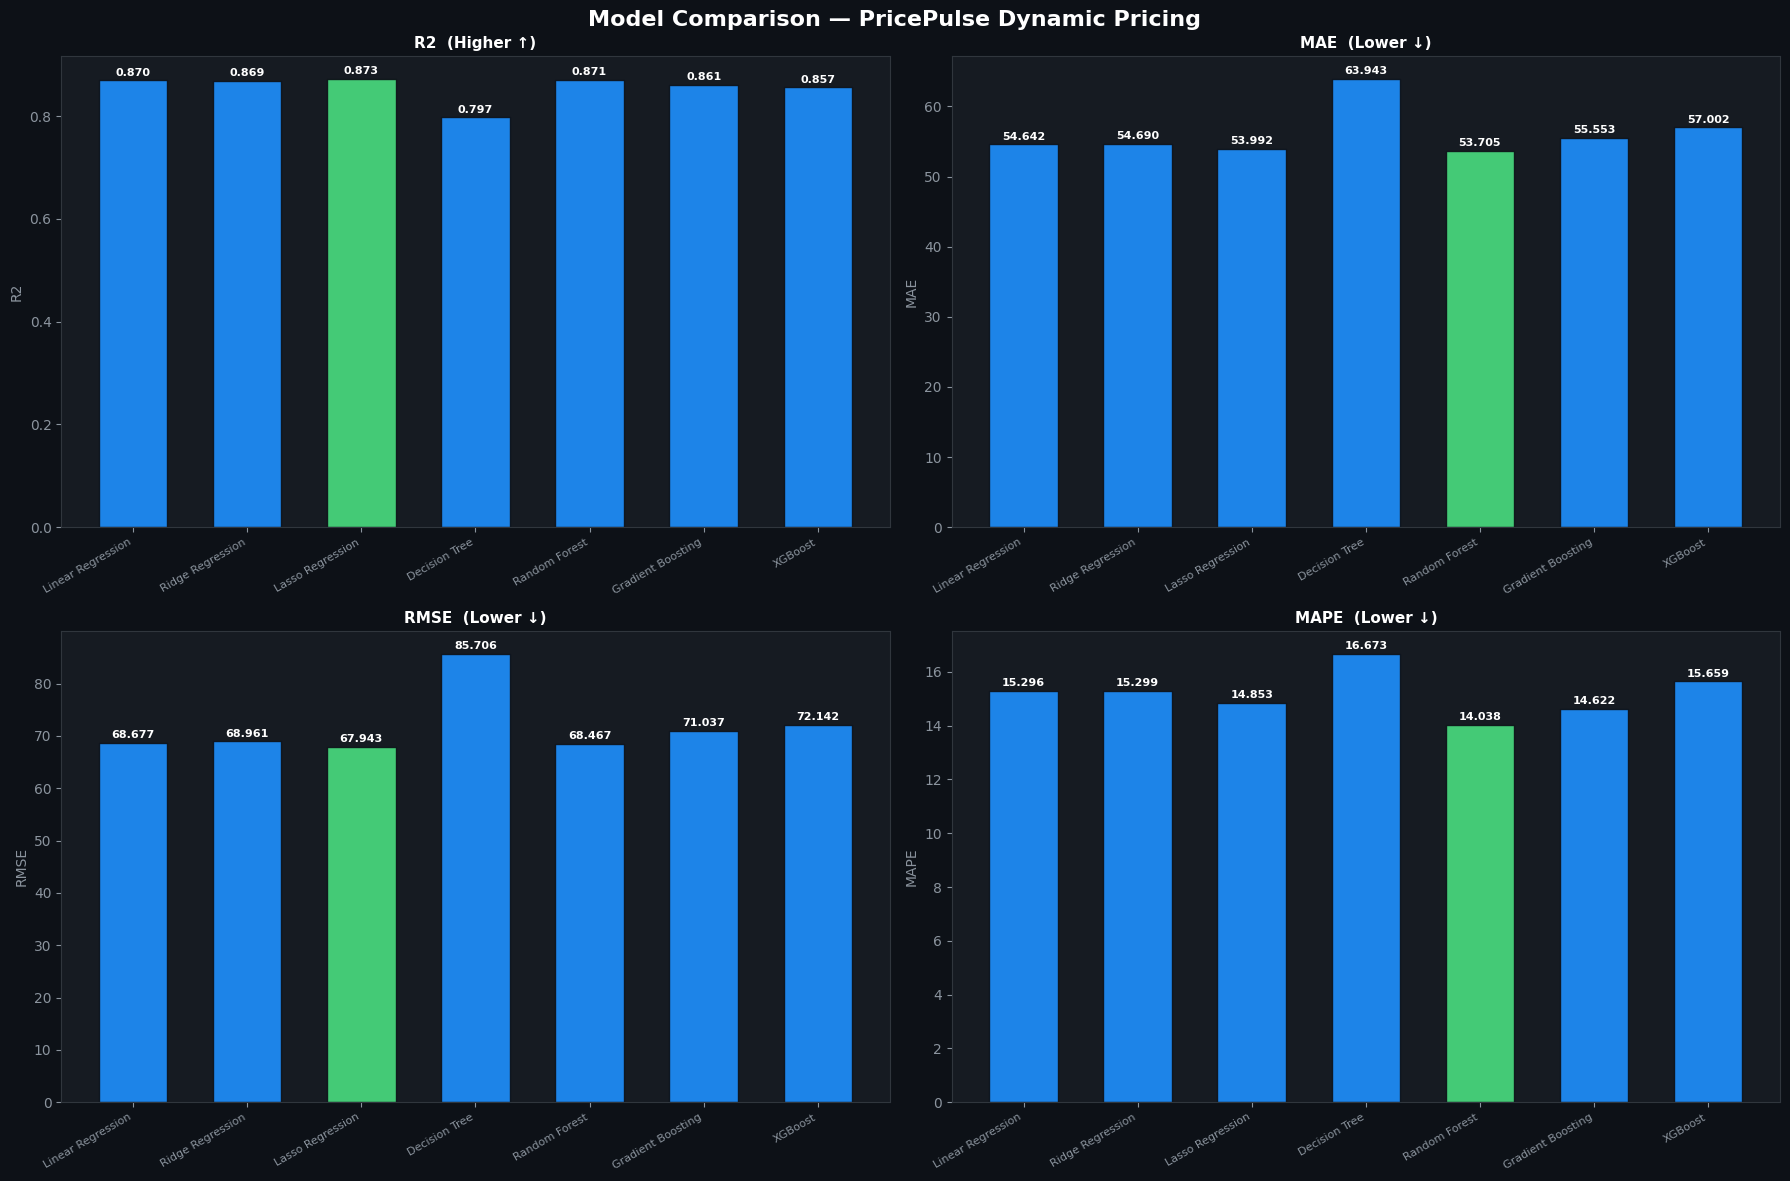

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('Model Comparison — PricePulse Dynamic Pricing', fontsize=16, fontweight='bold', color='white')
for ax in axes.flatten(): dark_ax(ax)
for ax, (metric, better) in zip(axes.flatten(),
        [('R2','Higher ↑'),('MAE','Lower ↓'),('RMSE','Lower ↓'),('MAPE','Lower ↓')]):
    vals = metrics_df[metric]
    colors_bar = [GRN if (better=='Higher ↑' and v == vals.max()) or(better!='Higher ↑' and v == vals.min()) else BLUE for v in vals.values]
    bars= ax.bar(range(len(vals)), vals.values, color=colors_bar, edgecolor=BG, alpha=0.9, width=0.6)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8, color='#8b949e')
    ax.set_title(f'{metric}  ({better})', color='white', fontweight='bold', fontsize=11)
    ax.set_ylabel(metric, color='#8b949e')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01, f'{val:.3f}', ha='center', fontsize=8, color='white', fontweight='bold')
 
plt.tight_layout()
plt.savefig(f'{PLOT}/08_model_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

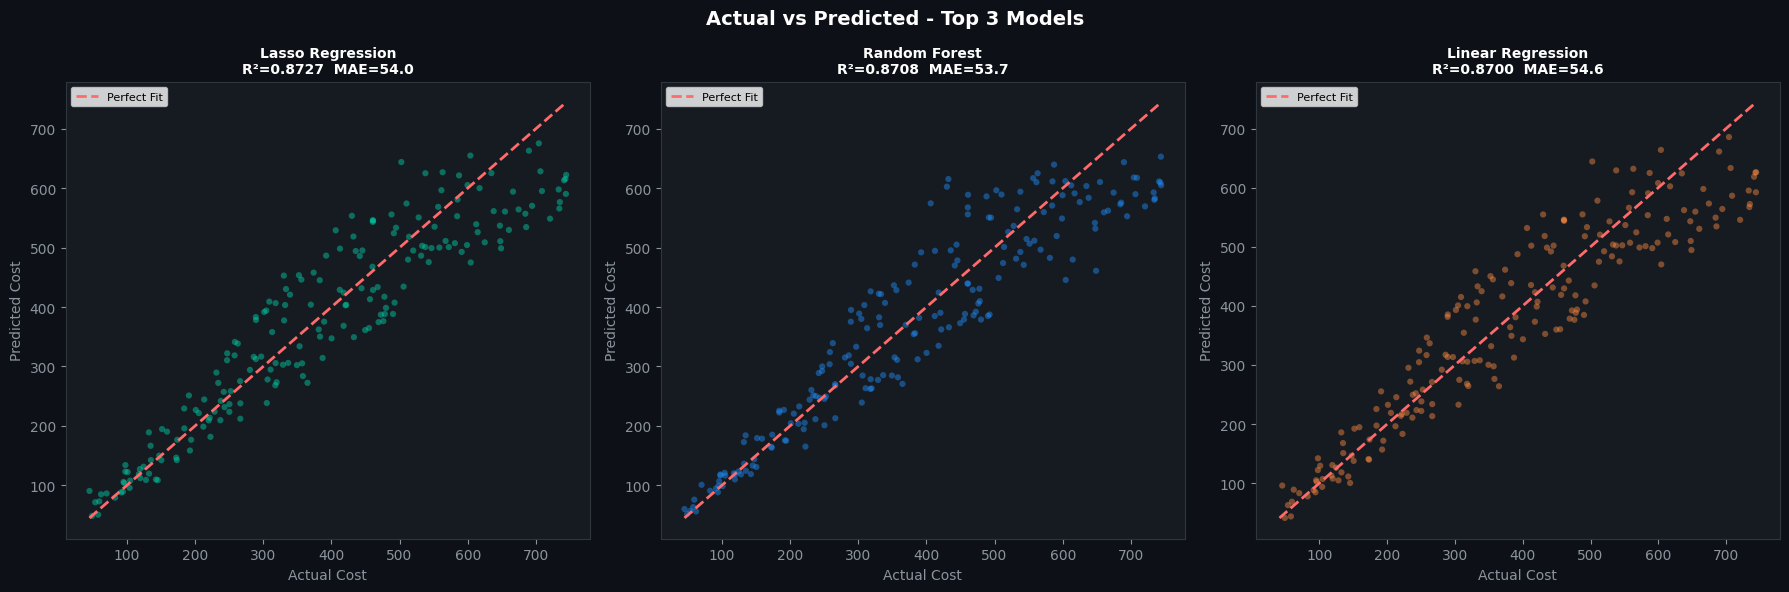

In [13]:
top3=sorted(results.items(),key=lambda x: x[1]['R2'], reverse=True)[:3]
fig,axes= plt.subplots(1,3,figsize=(18,6), facecolor=BG)
fig.suptitle('Actual vs Predicted - Top 3 Models', fontsize=14,fontweight='bold', color='white')
for ax in axes: dark_ax(ax)
for ax, (name,res), color in zip(axes, top3, [TEAL,BLUE,ORNG]):
    ax.scatter(y_test, res['y_pred'], alpha=0.45, s=20, c=color, edgecolors='none')
    mn,mx= min(y_test.min(), res['y_pred'].min()), max(y_test.max(), res['y_pred'].max())
    ax.plot([mn, mx], [mn, mx],color=ROSE, lw=2, ls='--', label='Perfect Fit')
    ax.set_xlabel('Actual Cost'); ax.set_ylabel('Predicted Cost')
    ax.set_title(f'{name}\nR²={res['R2']:.4f}  MAE={res['MAE']:.1f}', color='white', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOT}/09_actual_vs_predicted.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

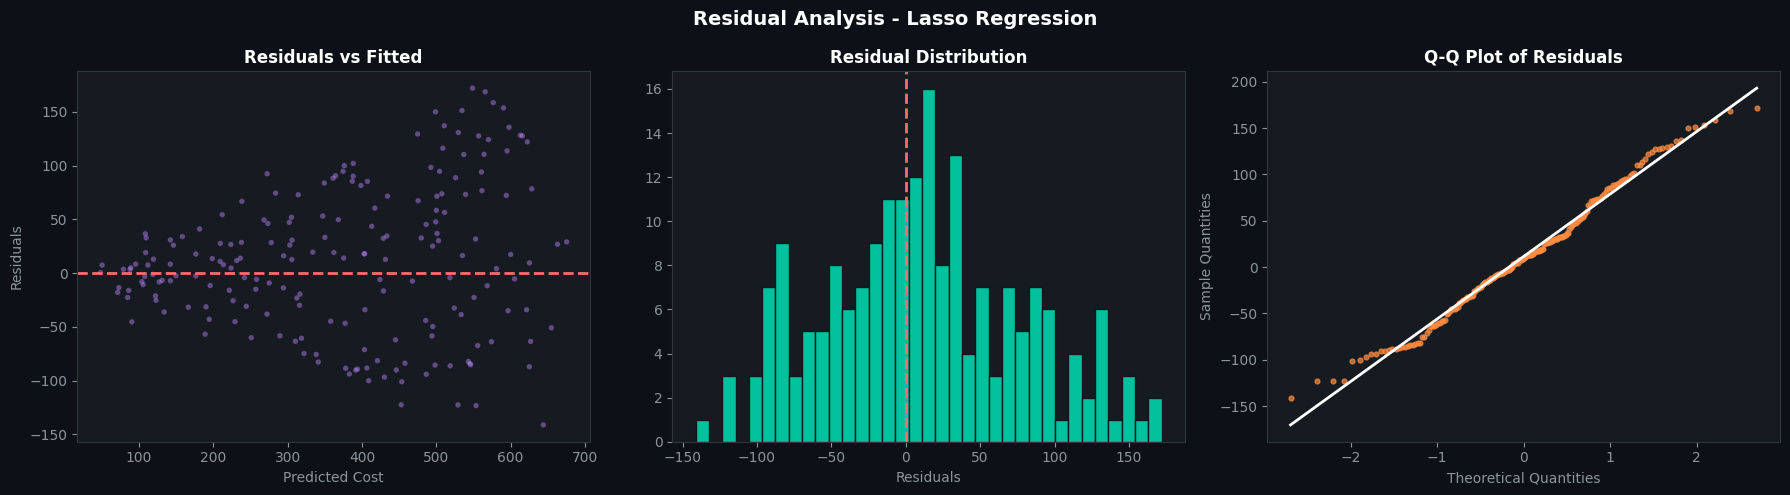

In [14]:
best_name= max(results, key=lambda x: results[x]['R2'])
best_res= results[best_name]
residuals=y_test-best_res['y_pred']

fig,axes= plt.subplots(1,3,figsize=(18,5), facecolor=BG)
fig.suptitle(f'Residual Analysis - {best_name}', fontsize=14,fontweight='bold',color='white')
for ax in axes: dark_ax(ax)
axes[0].scatter(best_res['y_pred'], residuals, alpha=0.45, s=15, c=PURP, edgecolor='none')
axes[0].axhline(0, color=ROSE, ls='--', lw=2)
axes[0].set_xlabel('Predicted Cost'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', color='white', fontweight='bold')

axes[1].hist(residuals, bins=35, color=TEAL, edgecolor=BG,alpha=0.9)
axes[1].axvline(0, color=ROSE, ls='--', lw=2)
axes[1].set_xlabel('Residuals'); axes[1].set_title('Residual Distribution', color='white', fontweight='bold')

osm_r, osr_r= stats.probplot(residuals, dist='norm')[0]
slope_r,intercept_r,_= stats.probplot(residuals, dist='norm')[1]
axes[2].scatter(osm_r, osr_r, color=ORNG, s=12, alpha=0.7)
axes[2].plot(osm_r, slope_r*np.array(osm_r)+intercept_r, color='white', lw=2)
axes[2].set_xlabel('Theoretical Quantities'); axes[2].set_ylabel('Sample Quantities')
axes[2].set_title('Q-Q Plot of Residuals', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOT}/10_residuals_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

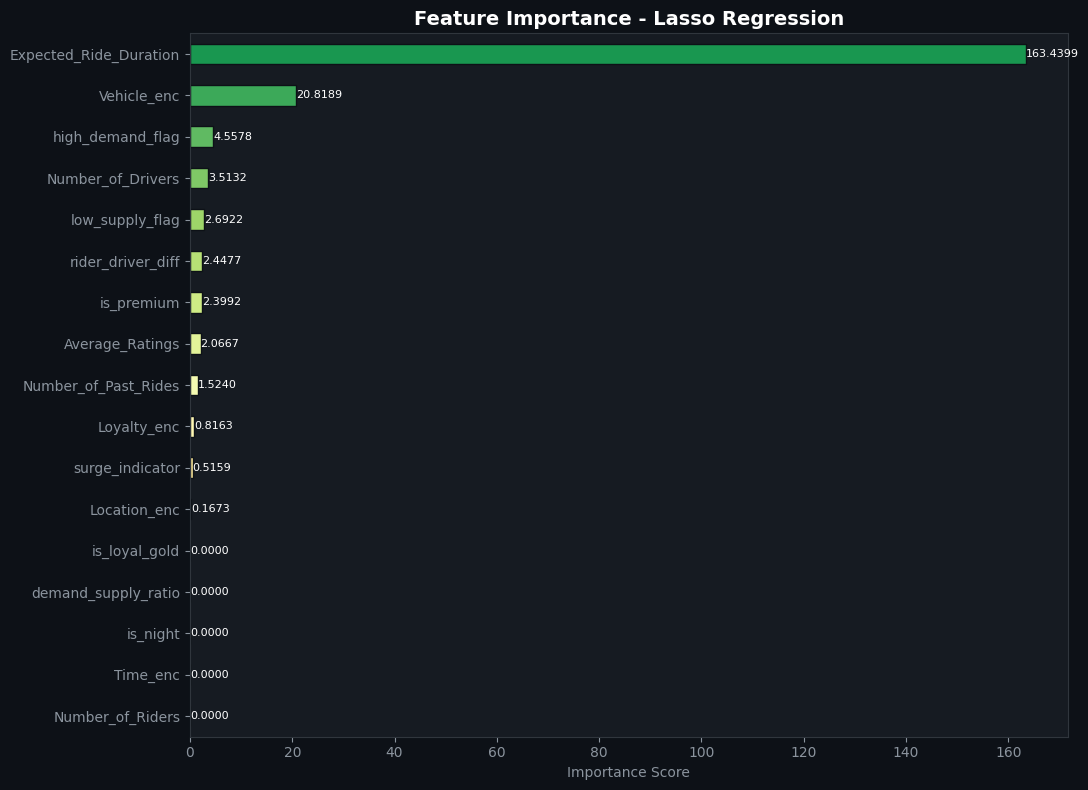

In [20]:
best_model= results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance_values = np.abs(best_model.coef_.flatten())
else:
    importance_values = None
if importance_values is not None:
    imp= pd.Series(importance_values, index=FEATURES).sort_values(ascending=True)
    colors_fi= plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(imp)))
    fig,ax= plt.subplots(figsize=(11,8), facecolor=BG)
    dark_ax(ax)
    imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor=BG)
    ax.set_title(f'Feature Importance - {best_name}', color='white', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, (idx,val) in enumerate(imp.items()):
        ax.text(val+0.001,i,f'{val:.4f}', va='center', fontsize=8, color='white')
    plt.tight_layout()
    plt.savefig(f'{PLOT}/11_feature_importance.png',dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

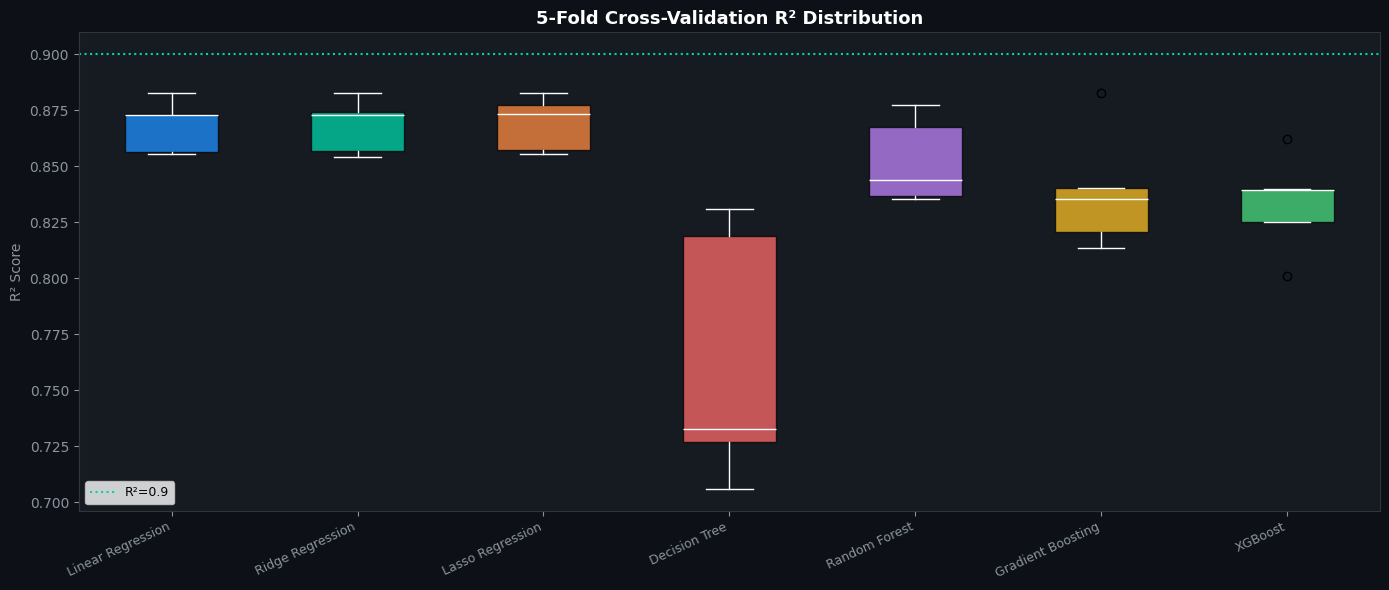

In [18]:
cv_all={}
for name, (model, use_scaled) in models.items():
    Xtr= X_train if use_scaled else X_train_raw
    cv_all[name]= cross_val_score(model, Xtr, y_train, cv=5, scoring='r2')

fig,ax=plt.subplots(figsize=(14,6), facecolor=BG)
dark_ax(ax)
bp= ax.boxplot([cv_all[n] for n in cv_all], patch_artist=True, notch=False)
for patch,color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for el in ['whiskers', 'caps','medians']:
    for item in bp[el]: item.set_color('white')
ax.set_xticks(range(1, len(cv_all)+1))
ax.set_xticklabels(cv_all.keys(), rotation=25, ha='right', color='#8b949e',fontsize=9)
ax.set_title('5-Fold Cross-Validation R² Distribution', color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('R² Score'); ax.axhline(0.9, color=TEAL, ls=':',lw=1.5,label='R²=0.9')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOT}/12_cross_validation.png',dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

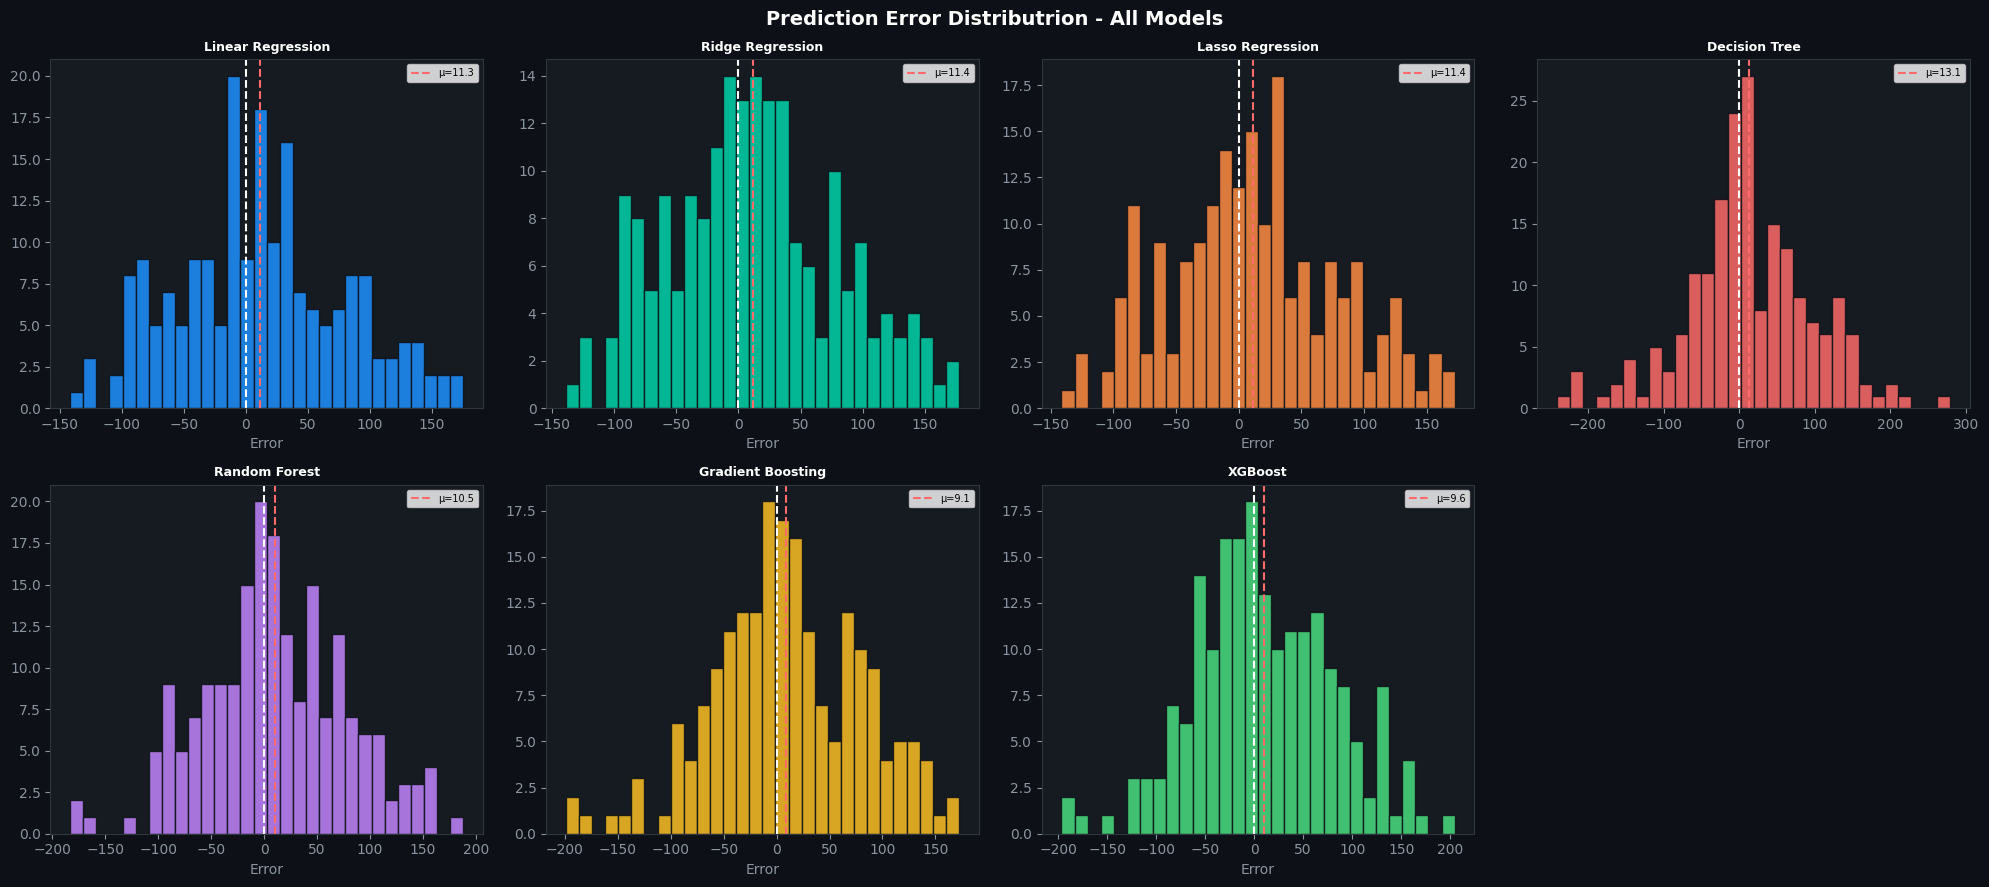

In [21]:
fig,axes=plt.subplots(2,4,figsize=(20,9),facecolor=BG)
fig.suptitle('Prediction Error Distributrion - All Models',fontsize=14, fontweight='bold',color='white')
axes_flat=axes.flatten()
for ax in axes_flat: dark_ax(ax)
for i,(name, res) in enumerate(results.items()):
    ax=axes_flat[i]
    err=y_test-res['y_pred']
    ax.hist(err, bins=30, color=PALETTE[i%len(PALETTE)],edgecolor=BG, alpha=0.85)
    ax.axvline(0, color='white', ls='--', lw=1.5)
    ax.axvline(err.mean(), color=ROSE, ls='--', lw=1.5, label=f'μ={err.mean():.1f}')
    ax.set_title(name, color='white', fontweight='bold', fontsize=9)
    ax.set_xlabel('Error'); ax.legend(fontsize=7)

axes_flat[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{PLOT}/13_error_distribution.png',dpi=150,bbox_inches='tight', facecolor=BG)
plt.show()

In [22]:
joblib.dump(best_model, f'{OUT}/best_model.pkl')
np.save(f'{OUT}/best_y_pred.npy', best_res['y_pred'])
with open(f'{OUT}/best_model_name.txt', 'w') as f: f.write(best_name)
 
print(f"BEST MODEL : {best_name}")
print(f"R² : {best_res['R2']:.4f}")
print(f"MAE : {best_res['MAE']:.4f}")
print(f"RMSE : {best_res['RMSE']:.4f}")
print(f"MAPE : {best_res['MAPE']:.2f}%")
print(f"CV R² : {best_res['CV_R2']:.4f}")

BEST MODEL : Lasso Regression
R² : 0.8727
MAE : 53.9916
RMSE : 67.9432
MAPE : 14.85%
CV R² : 0.8691


In [23]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Difference': y_test - y_pred,
    'Percentage_Err': np.abs((y_test - y_pred) / y_test) * 100
})

print(comparison.head(10))

       Actual   Predicted  Difference  Percentage_Err
0  119.594073  125.361115   -5.767041        4.822180
1  556.662929  617.228088  -60.565160       10.880042
2  674.648504  580.575073   94.073430       13.944066
3  184.242945  238.325150  -54.082205       29.353745
4  624.986010  498.453217  126.532793       20.245700
5  512.449393  483.128387   29.321005        5.721737
6  476.201996  419.842072   56.359925       11.835298
7  104.056073   90.642426   13.413647       12.890787
8  382.929938  433.534393  -50.604455       13.215069
9  581.151457  465.104828  116.046629       19.968397
